<a href="https://colab.research.google.com/github/ninakhn/CMSC320FinalProj/blob/main/Final_Submission_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DC Felony Sentencing Analysis
## Fall 2024 Data Science Project
### Authors
Nina Khilnani, Diya Peechara, Rahil Shiraz, Maanya Upadhyay, Saachi Samdani

### Contributions
Nina Khilnani (E, F, H)
I worked on analyzing the results from our models, like looking at how Model 4 performed when we removed some of the offense-level features. I also made some visualizations including the loss/MAE curves for the neural network, and helped write up the conclusion.

Diya Peechara (A, D, G)
Contributed to the original project idea of analyzing bias in DC felony sentencing. Designed the machine learning approach, comprising of linear regression, random forest, and neural network models.

Rahil Shiraz (D, E)
I helped with the model design side, mainly deciding on features and setting up the one-hot encoding and train/test split. Once the models were trained I ran the evaluations and compared performance across all five using MAE, RMSE, and R².

Maanya Upadhyay (A, B, H)
I helped come up with the project idea and narrow down our research questions around bias in criminal justice. On the data side I worked on loading and cleaning all three datasets, which involved a lot of dealing with missing values and making sure the categorical variables were standardized.


Saachi Samdani: B, C, F
I contributed to the code for data curation and hypothesis testing. In terms of the written portion, I wrote the introduction, hypothesis testing, and part of both the data curation and machine learning sections.



**Introduction:**
The purpose of this project is to analyze felony sentencing in the District of Columbia using the entire data science pipeline. A main goal of the United States criminal justice system is to ensure equal protection under the law for all individuals. However, many are concerned that bias is prevalent throughout the steps of the criminal justice system, especially sentencing. We are interested in understanding whether factors such as race, gender, age, etc. are significant contributors to sentencing outcomes within D.C. Our overall topic first addresses the key attributes that influence sentencing lengths in general. While we expect attributes such as the type of offense committed or the severity of the crime to be the best predictors, we are also interested in whether or not demographic attributes have any impact on sentencing lengths or even offense types. We are also curious about general trends regarding crime, whether that be the relationship between certain demographics and qualities of a crime, or even types of crimes and their relationship with sentencing. Answering these questions are important in better understanding bias in criminal justice systems. Identifying such issues using a data driven methodology is the first step towards solving such issues.


# Data Curation and Preprocessing

This section cleans and preprocesses the felony sentencing dataset. We remove unnecessary columns, handle missing values, standardize categorical variables, and engineer new features such as total_fine and serve_ratio.



# Data Preprocessing and Summary Statistics

Import:

In [ ]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import numpy as np

In [ ]:
sentences_df = pd.read_csv('/content/Felony_Sentences.csv')
arrests_df = pd.read_csv('/content/Felony_Arrest_Charges_in_2016.csv')
crimes_df = pd.read_csv('/content/Felony_Crime_Incidents_in_2016.csv')

In [ ]:
import pandas as pd
import numpy as np

def clean_dataset(df):
    df = df.copy()

    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    df = df.drop_duplicates()

    id_cols = ['ccn', 'generic_case_id']
    for col in id_cols:
        if col in df.columns:
            df = df.dropna(subset=[col])

    for col in df.columns:
        if 'date' in col or 'created' in col or 'edited' in col:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    for col in df.columns:
        if df[col].dtype == 'object':
            converted = pd.to_numeric(df[col], errors='coerce')
            if converted.notna().sum() > 0:
                df[col] = converted

    for col in df.columns:
        if df[col].dtype in [np.float64, np.int64]:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna("Unknown")

    categorical_cols = ['race', 'gender', 'sex', 'ethnicity']

    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.upper().str.strip()

    return df

arrests = clean_dataset(arrests_df)
crimes = clean_dataset(crimes_df)
sentences = clean_dataset(sentences_df)

arrests.head()
crimes.head()
sentences.head()

,rid,generic_case_id,generic_offender_id,charge_number,sentence_year,race,gender,age_group,offense,offense_type,...,sentence_probation_months,vvca_amt,fine_amt,restitution_amt,fine_suspended_amt,gis_id,globalid,created,edited,objectid
0,39,7548270,7241253,3,2020,BLACK,M,22-30,Aggravated Assault Knowingly,Violent,...,0.0,100,0.0,0.0,0.0,Felony_Sentences_1,{F8F4B0A9-C6CD-4D91-B878-DAFA4C9FF3CE},Unknown,Unknown,1
1,40,7548270,7241253,7,2020,BLACK,M,22-30,Unlawful Possession of a Firearm,Weapon,...,0.0,100,0.0,0.0,0.0,Felony_Sentences_2,{2845886A-02B7-4D93-80DA-9468C5946DB8},Unknown,Unknown,2
2,41,2815732,5135695,3,2020,BLACK,M,22-30,Unlawful Possession of a Firearm (Crime of Vio...,Weapon,...,0.0,100,0.0,0.0,0.0,Felony_Sentences_3,{4BF74DE0-05D1-4590-9F9E-07A77C54DA53},Unknown,Unknown,3
3,42,2815732,5135695,4,2020,BLACK,M,22-30,Unlawful Possession of a Firearm (Crime of Vio...,Weapon,...,0.0,100,0.0,0.0,0.0,Felony_Sentences_4,{F7E0410A-8480-4B64-8760-59513962459A},Unknown,Unknown,4
4,43,7703087,7383706,1,2020,BLACK,F,61-70,Voluntary Manslaughter,Homicide,...,0.0,100,0.0,0.0,0.0,Felony_Sentences_5,{F5E5096E-62D8-4162-BD74-C588790DD805},Unknown,Unknown,5


In [ ]:
print(sentences_df.dtypes)
print(sentences_df.isna().sum())

RID                            int64
GENERIC_CASE_ID                int64
GENERIC_OFFENDER_ID            int64
CHARGE_NUMBER                  int64
SENTENCE_YEAR                  int64
RACE                          object
GENDER                        object
AGE_GROUP                     object
OFFENSE                       object
OFFENSE_TYPE                  object
HOMICIDE_TYPE                 object
OFFENSE_SEVERITY_GROUP        object
SENTENCE_TYPE                 object
SENTENCE_IMPOSED_MONTHS      float64
SENTENCE_SUSPENDED_MONTHS    float64
SENTENCE_TO_SERVE_MONTHS     float64
SENTENCE_PROBATION_MONTHS    float64
VVCA_AMT                       int64
FINE_AMT                     float64
RESTITUTION_AMT              float64
FINE_SUSPENDED_AMT           float64
GIS_ID                        object
GLOBALID                      object
CREATED                      float64
EDITED                       float64
OBJECTID                       int64
dtype: object
RID                     

In [ ]:
import pandas as pd
import numpy as np

numeric_cols = [
    'sentence_imposed_months',
    'sentence_suspended_months',
    'sentence_to_serve_months',
    'sentence_probation_months',
    'vvca_amt',
    'fine_amt',
    'restitution_amt',
    'fine_suspended_amt'
]

for col in numeric_cols:
    if col in sentences.columns:
        sentences[col] = pd.to_numeric(sentences[col], errors='coerce')
        median_val = sentences[col].median()
        sentences[col] = sentences[col].fillna(median_val)

for col in ['created', 'edited']:
    if col in sentences.columns:
        sentences[col] = pd.to_datetime(sentences[col], errors='coerce')
        sentences[col] = sentences[col].fillna(pd.Timestamp('1900-01-01')) # Placeholder date

categorical_cols = [
    'race', 'gender', 'age_group',
    'offense', 'offense_type',
    'offense_severity_group', 'sentence_type',
    'homicide_type'
]

for col in categorical_cols:
    if col in sentences.columns:
        sentences[col] = sentences[col].fillna('Unknown')

cols_to_drop = [
    'rid',
    'generic_case_id',
    'generic_offender_id',
    'gis_id',
    'globalid',
    'objectid'
]

sentences = sentences.drop(columns=cols_to_drop, errors='ignore')

sentences['total_fine'] = 0.0
for col in ['vvca_amt', 'fine_amt', 'restitution_amt']:
    if col in sentences.columns:
        sentences['total_fine'] += sentences[col]

if 'sentence_imposed_months' in sentences.columns and 'sentence_to_serve_months' in sentences.columns:
    imposed_months = sentences['sentence_imposed_months'].replace(0, np.nan)
    sentences['serve_ratio'] = sentences['sentence_to_serve_months'] / imposed_months
    sentences['serve_ratio'] = sentences['serve_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)
else:
    sentences['serve_ratio'] = 0.0

print("Final Cleaned Sentences DataFrame Info:")
print(sentences.info())

print("\nSummary Statistics After Cleaning:")
print(sentences.describe())

print("\nMissing Values After Final Cleaning:")
print(sentences.isna().sum())

Final Cleaned Sentences DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24676 entries, 0 to 24675
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   charge_number              24676 non-null  int64         
 1   sentence_year              24676 non-null  int64         
 2   race                       24676 non-null  object        
 3   gender                     24676 non-null  object        
 4   age_group                  24676 non-null  object        
 5   offense                    24676 non-null  object        
 6   offense_type               24676 non-null  object        
 7   homicide_type              24676 non-null  object        
 8   offense_severity_group     24676 non-null  object        
 9   sentence_type              24676 non-null  object        
 10  sentence_imposed_months    24676 non-null  float64       
 11  sentence_suspended_months  

Parse

In [ ]:
for df in [arrests, crimes, sentences]:
    for col in ['ccn', 'generic_case_id']:
        if col in df.columns:
            df[col] = df[col].astype(str)

def convert_dates(df):
    for col in df.columns:
        if 'date' in col or 'created' in col or 'edited' in col:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    return df

arrests = convert_dates(arrests)
crimes = convert_dates(crimes)
sentences = convert_dates(sentences)


Organize

In [ ]:
if 'mpd_arrest_date' in arrests.columns:
    arrests = arrests.sort_values(by='mpd_arrest_date', na_position='last')

if 'offense_report_date' in crimes.columns:
    crimes = crimes.sort_values(by='offense_report_date', na_position='last')

if 'created' in sentences.columns:
    sentences = sentences.sort_values(by='created', na_position='last')

arrests = arrests[sorted(arrests.columns)]
crimes = crimes[sorted(crimes.columns)]
sentences = sentences[sorted(sentences.columns)]

print("Arrests shape:", arrests.shape)
print("Crimes shape:", crimes.shape)
print("Sentences shape:", sentences.shape)

print("\nArrests columns:", arrests.columns.tolist())
print("\nCrimes columns:", crimes.columns.tolist())
print("\nSentences columns:", sentences.columns.tolist())

# Exploratory Data Analysis

We begin by exploring relationships between demographic variables and sentencing outcomes. The following statistical tests and visualizations help determine whether variables such as gender and offense type are associated with sentencing differences.

# Data Exploration


We utilize three different statistical methods for initial hypothesis testing. For the first method, we use a chi squared test in order to assess the relationship between gender and offense type. The null hypothesis for this test is that the gender of the individual does not have an effect on the type of offense they commit, with the alternative hypothesis being that gender does have an effect on the type of offense. A chi squared test is used because both variables are categorical. The low resulting p-value allows us to reject the null hypothesis that the gender of the individual does not have an effect on the type of offense they commit. To supplement this test, we create a grouped bar graph that displays the number of each type of offense committed (in the dataset) among each gender. The plot reveals that a large proportion of offenses in the dataset are committed by male individuals.

**Statistical Method 1: Chi Squared Test**

Null Hypothesis: The gender of the individual does not have an effect on the type of offense they commit

Alternative Hypothesis: The gender of the individual does have an effect on the type of offense they commit

Both gender and type of offense are categorical variables, which is why I chose a chi squared test as my analysis technique.

In [ ]:
import scipy.stats
from scipy.stats.contingency import crosstab

contingency_table = pd.crosstab(sentences['gender'],sentences['offense_type'])
contingency_table


offense_type,Drug,Homicide,Other,Property,Sex,Violent,Weapon
gender,,,,,,,
F,740,35,372,163,18,483,82
M,5303,722,1999,2665,702,6301,4864
UNKNOWN,63,5,24,27,4,68,36


In [ ]:
from scipy.stats import chi2_contingency
test_res = chi2_contingency(contingency_table)
test_res.pvalue

np.float64(3.99483558837948e-142)

Based on the p-value, we can reject the null hypothesis that the gender of the individual does not have an effect on the type of offense they commit.

Plot 1:

[Text(0.5, 1.0, 'Number of Offenses by Type and Gender'),
 Text(0.5, 0, 'Offense Type'),
 Text(0, 0.5, 'Count')]

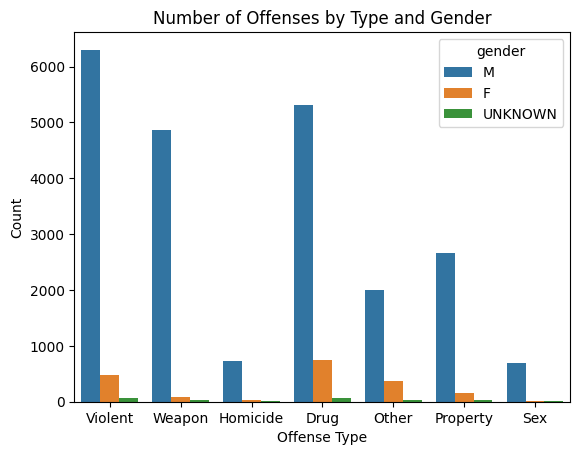

In [ ]:
plot1 = sns.countplot(sentences, x='offense_type', hue='gender')
plot1.set(title='Number of Offenses by Type and Gender', xlabel='Offense Type',
          ylabel='Count')

The plot depicts how the likelihood for an individual to commit an offense in general is different across genders, and the types of crimes a person is likely to commit also varies across gender. The plot reveals that a large proportion of offenses in the dataset are committed by male indivi

**Statistical Method 2: T-Test**

For the second hypothesis test, we use the t-test method. The null hypothesis is that the gender of the individual does not have an effect on the length of sentencing, with the alternative hypothesis being that the gender of the individual does have an effect on the length of sentencing.  Based on the low p-value, we reject the null hypothesis. Paired with this test is another grouped bar graph displaying different offense types and their average sentence length, grouped by gender. This plot is interesting because it reveals that even among the same offense types, there is a difference in sentence length between male and females. For instance, the average sentence length for a male individual who committed homicide is over 200 months, while the average sentence length for a female who committed homicide is under 150 months. This implies a bias in sentencing length.

Null Hypothesis: The gender of the individual does not have an effect on the length of sentencing

Alternative Hypothesis: The gender of the individual does have an effect on the length of sentencing

In [ ]:
from scipy.stats import ttest_ind

results = []

for offense in sentences['offense_type'].unique():

    subset = sentences[sentences['offense_type'] == offense]

    male = subset[subset['gender']=='M']['sentence_imposed_months'].dropna()
    female = subset[subset['gender']=='F']['sentence_imposed_months'].dropna()

    t_stat, p_val = ttest_ind(male, female, equal_var=False)

    results.append([offense, len(male), len(female), t_stat, p_val])

results_df = pd.DataFrame(results,
                          columns=['Offense',
                                   'Male Count',
                                   'Female Count',
                                   'T-statistic',
                                   'P-value'])

print(results_df.sort_values('P-value'))

    Offense  Male Count  Female Count  T-statistic       P-value
0   Violent        6301           483    16.761622  5.437721e-54
3      Drug        5303           740    14.747952  9.376724e-47
4     Other        1999           372     9.539208  9.127450e-21
6       Sex         702            18     6.947216  2.065917e-07
1    Weapon        4864            82     5.586918  2.566184e-07
5  Property        2665           163     5.278304  3.038192e-07
2  Homicide         722            35     4.009501  2.614316e-04


Based on the p-values, we can reject the null hypothesis. Gender may affect length of sentencing.

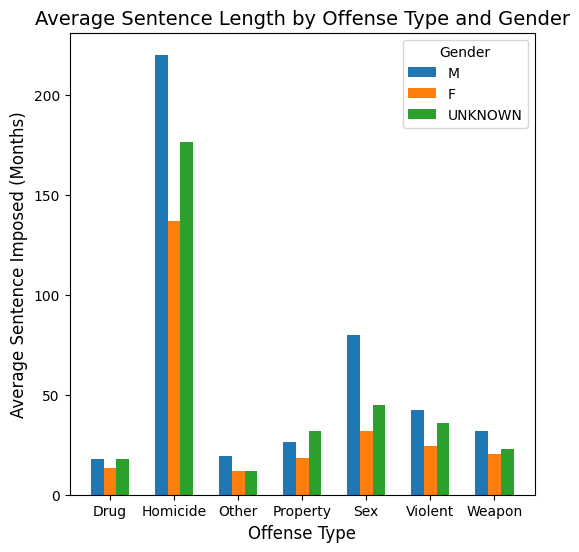

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

mean_g = sentences.groupby(['offense_type', 'gender'])['sentence_imposed_months'].mean().reset_index()

offense_types = mean_g['offense_type'].unique()
genders = ['M', 'F', 'UNKNOWN']

bar_width = 0.2
index = np.arange(len(offense_types))

fig, ax = plt.subplots(figsize=(6, 6))

for i, gender in enumerate(genders):
    gender_data = mean_g[mean_g['gender'] == gender]

    gender_means = gender_data.set_index('offense_type')['sentence_imposed_months'].reindex(offense_types).fillna(0)

    bar_position = index + (i - (len(genders) - 1) / 2) * bar_width
    ax.bar(bar_position, gender_means, bar_width, label=gender)

ax.set_xlabel('Offense Type', fontsize=12)
ax.set_ylabel('Average Sentence Imposed (Months)', fontsize=12)
ax.set_title('Average Sentence Length by Offense Type and Gender', fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(offense_types)
ax.legend(title='Gender')
plt.show()

This plot shows how men typically have a longer sentence than women. This supports the statement made from the T-test on how gender can play a role in sentence length.

**Statistical Method 3: ANOVA**

Our final statistical method used for hypothesis testing is an analysis of variance (ANOVA). The null hypothesis for this test is that the type of offense does not affect the average length of sentencing, while the alternative hypothesis is that type of offense does have an effect on the average length of sentencing. As expected, the low p-value and large F-statistic allows us to reject the null hypothesis. To accompany this test, we created boxplots for each type of offense to display the distribution of sentence lengths. Here we see that homicides have significantly higher average sentence lengths than any other crime, due to the severity of the crime.
Overall, these tests provide us with some baseline understanding of our data. It allows us to further understand important relationships between gender, offense types, and sentence lengths. This teaches us more about demographic trends in crime, as intended. It also serves as a sanity check, as we found that offense type influences sentencing lengths, as expected.

Null Hypothesis: The type of offense doesn't have an effect on the average length of sentencing.

Alternative Hypothesis: The type of offense has an effect on the averge length of sentencing.

In [ ]:
from scipy.stats import f_oneway

anova_groups = []

for offense in sentences['offense_type'].dropna().unique():
    group = sentences[sentences['offense_type'] == offense]['sentence_imposed_months'].dropna()
    if len(group) > 1:
        anova_groups.append(group)

anova_stat, anova_p = f_oneway(*anova_groups)

print("ANOVA F-statistic:", anova_stat)
print("ANOVA p-value:", anova_p)

ANOVA F-statistic: 2971.9816722462137
ANOVA p-value: 0.0


Based on the ANOVA resultls, the p-value is 0 and the F-statistic is very large, so we can reject the null hypothesis as sentence length differs across the various offense types.

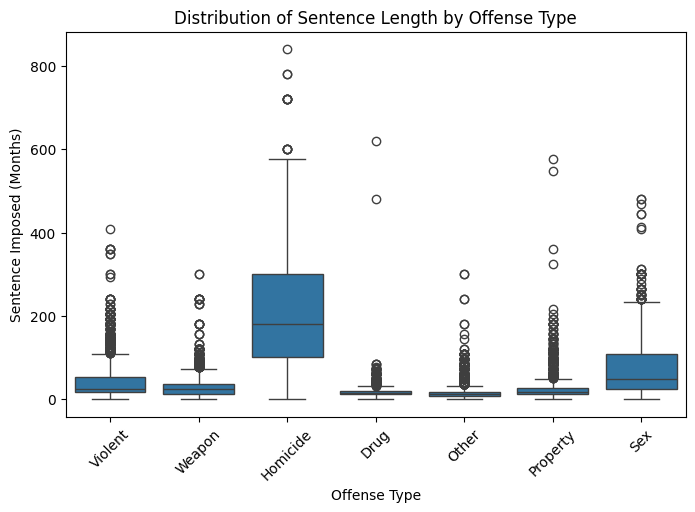

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
plot2 = sns.boxplot(data=sentences, x='offense_type', y='sentence_imposed_months')

plot2.set(
    title='Distribution of Sentence Length by Offense Type',
    xlabel='Offense Type',
    ylabel='Sentence Imposed (Months)'
)

plt.xticks(rotation=45)
plt.show()

The plot shows that sentence lengths vary a lot across the different types of offense. Some have higher median sentences and wider spreads, supporting the ANOVA results and helping us reject the null hypothesis.



---


#NEW MATERIAL, MODEL TRAINING, FEATURE ENGINEERING


---



## Machine Learning Model: Predicting Sentence Length

Our overarching goal for the machine learning section is to identify the key attributes that influence felony sentencing lengths in D.C., and to assess whether demographic factors like race, gender, and age play a role. To begin, we define our target and feature variables. The target variable is the sentence length in months (‘sentence_imposed_months’), while our feature variables include charge number, year of sentence, race, gender, age, offense, offense type, homicide type, and offense severity group. We use one-hot encoding in order to handle the categorical features. Next, we split the data into a training and testing set in order to prevent overfitting.


In [ ]:
target = 'sentence_imposed_months'
y = sentences[target]

# defining the features, excluding direct outcomes of sentencing or derived features
# Keeping charge_number, sentence_year, and the suggested categorical features
features = [
    'charge_number',
    'sentence_year',
    'race',
    'gender',
    'age_group',
    'offense',
    'offense_type',
    'homicide_type',
    'offense_severity_group',
]
X = sentences[features]

# find categorical and numerical features
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(exclude='object').columns

print(f"Target variable: {target}")
print(f"Number of features: {len(features)}")
print(f"Categorical features: {list(categorical_features)}")
print(f"Numerical features: {list(numerical_features)}")

# one-hot Encoding parrt
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print(f"\nShape of features DataFrame after one-hot encoding is as follows: {X.shape}")
print("First 5 rows of features after the encoding:")
display(X.head())

Target variable: sentence_imposed_months
Number of features: 9
Categorical features: ['race', 'gender', 'age_group', 'offense', 'offense_type', 'homicide_type', 'offense_severity_group']
Numerical features: ['charge_number', 'sentence_year']

Shape of features DataFrame after one-hot encoding is as follows: (24676, 270)
First 5 rows of features after the encoding:


,charge_number,sentence_year,race_BLACK,race_HISPANIC,race_NATIVE AMERICAN,race_OTHER OR UNKNOWN,race_PACIFIC ISLANDER,race_WHITE,gender_M,gender_UNKNOWN,...,offense_severity_group_D4,offense_severity_group_M1,offense_severity_group_M2,offense_severity_group_M3,offense_severity_group_M4,offense_severity_group_M5,offense_severity_group_M6,offense_severity_group_M7,offense_severity_group_M8,offense_severity_group_M9
0,3,2020,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
1,7,2020,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,3,2020,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,4,2020,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
4,1,2020,True,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


### splitting the dataset

in this section we split the data into training and testing data. Lets us train and test on different data. Prevents overfitting.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (19740, 270)
Testing features shape: (4936, 270)
Training target shape: (19740,)
Testing target shape: (4936,)


### Model 1: Linear Regression

-----------------------------
Linear Regression Model Evaluation
Mean Absolute Error (MAE): 11.63
Mean Squared Error (MSE): 643.57
Root Mean Squared Error (RMSE): 25.37
R-squared (R2): 0.79

-----------------------------
Top 10 Features by Coefficients from Linear Regression


,Feature,Coefficient,Absolute_Coefficient
126,offense_Felony Murder,284.961450,284.961450
160,offense_Murder I,245.638901,245.638901
33,offense_ASLT W/I ROB WHILE ARMED,227.148257,227.148257
213,offense_Sodomy,-171.972504,171.972504
23,offense_2ND DEG MURDER W/ARMED,-139.246988,139.246988
262,offense_severity_group_M2,126.027387,126.027387
32,offense_ASLT W/I KILL WHILE ARMED ...,-121.079843,121.079843
123,offense_FELONY MURDER W/ARMED,-118.464177,118.464177
28,offense_ARMED BURGLARY I,-110.085745,110.085745
159,offense_Murder 1 Premeditated,-72.345142,72.345142


/tmp/ipykernel_6978/3674560651.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coefs.head(20), palette='viridis')


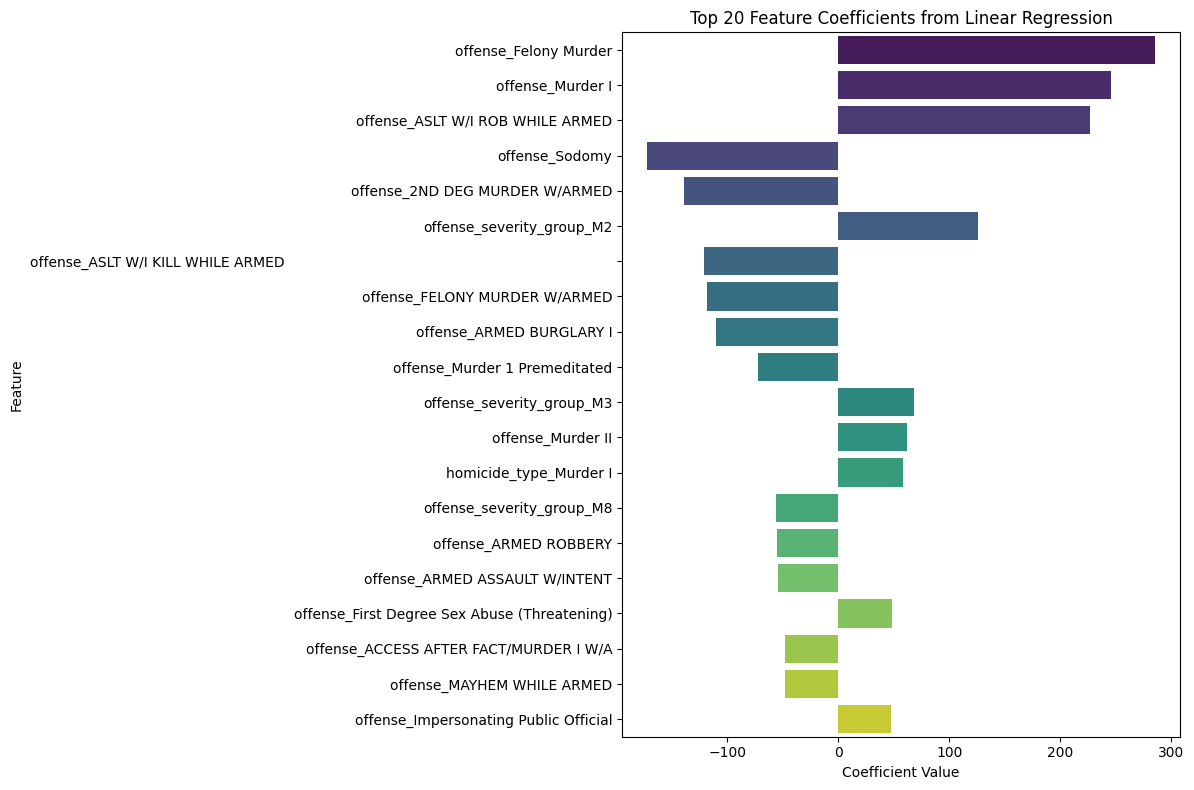

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lr = lin_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("-----------------------------")
print("Linear Regression Model Evaluation")
print(f"Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"R-squared (R2): {r2_lr:.2f}")

coefs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lin_model.coef_
})
coefs['Absolute_Coefficient'] = np.abs(coefs['Coefficient'])
coefs = coefs.sort_values(by='Absolute_Coefficient', ascending=False)

print("\n-----------------------------")
print("Top 10 Features by Coefficients from Linear Regression")
display(coefs.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coefs.head(20), palette='viridis')
plt.title('Top 20 Feature Coefficients from Linear Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

For this section, we chose linear regression over classification or clustering. Linear regression seemed to be the most useful for a number of reasons. First, our target variable is continuous, the sentence length seems to range from 0 to 840 months. Linear regression naturally seemed better to predict the continuous variable outcomes. Secondly, our EDA showed that there was likely a linear relationship. The ANOVA test showed that the offense type had a strong effect on sentence length. For these reasons, linear regression seemed to be the best approach to predicting the variable.

The first model we employ is a linear regression to predict sentence length. We start by fitting the model on the training data and then predicting the target variable using the test set. In order to evaluate the model we calculate the mean absolute error (MAE), mean squared error (MSE), root mean squared error (RMSE), and R-squared (R2). The R2 is 0.79, which means that the model explains about 79% of the variance in sentence length, which is a strong result. The MAE, 11.63 months, tells us that on average, our predictions are off by a little less than a year. This result is not negligible, but it is reasonable because the sentence lengths in the data set are from 0 to 840 months and have a standard deviation of 53 months. The RMSE, 25.37, is higher than the MAE, meaning the model makes large errors occasionally.

We also chose to display the top 10 features by coefficients (absolute value) from the linear regression. These features are the ones that influence expected sentence length the most, as determined by the linear regression model.  Essentially, holding all other features constant, if a crime/observation has a specific feature (value of 1 or True for that column), the predicted sentence length in months increases by the amount of its coefficient, relative to an observation not having that feature. As seen below, the top 10 features are all related to the type of offense of the crime. The accompanying visualization plots the coefficient values of the top 20 features in order to help the reader better understand even more features that have an impact on the target variable. This plot allows the reader to see that the most important features all have to do with the type of crime committed, as expected. We expand on these results with the subsequent models.


### Model 2: Random Forest Regressor


-----------------------------
Random Forest Regressor Model Evaluation
Mean Absolute Error (MAE): 11.64
Mean Squared Error (MSE): 632.13
Root Mean Squared Error (RMSE): 25.14
R-squared (R2): 0.80

-----------------------------
Top 10 Features by Importance, Random Forest


,Feature,Importance
256,homicide_type_Unknown,0.278160
263,offense_severity_group_M3,0.103633
0,charge_number,0.083313
248,offense_type_Homicide,0.080411
265,offense_severity_group_M5,0.076121
1,sentence_year,0.073892
262,offense_severity_group_M2,0.052618
261,offense_severity_group_M1,0.038135
254,homicide_type_Murder I,0.030361
161,offense_Murder II,0.027686


/tmp/ipykernel_6978/3506287350.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances_rf.head(20), palette='viridis')


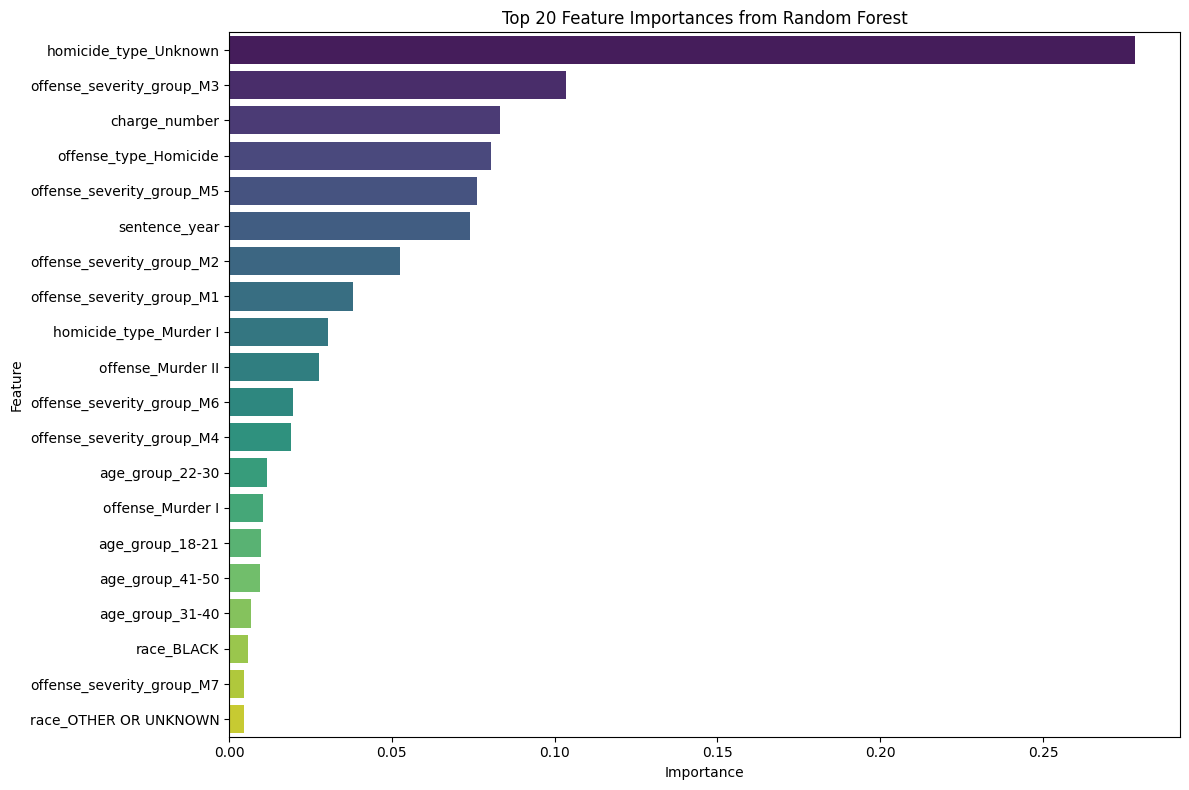

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("-----------------------------")
print("Random Forest Regressor Model Evaluation")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

feature_importances_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
feature_importances_rf = feature_importances_rf.sort_values(by='Importance', ascending=False)

print("\n-----------------------------")
print("Top 10 Features by Importance, Random Forest")
display(feature_importances_rf.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances_rf.head(20), palette='viridis')
plt.title('Top 20 Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The second model we employ is random forest with 100 decision trees. After seeing the results, we learn that the random forest regressor performs almost identically to linear regression. It has a slightly better R2 of 0.8 and a slightly lower RMSE of 25.14 months. The RMSE remains the same, which is 25.37 months. Due to the similarity and consistency of these 2 different models, our confidence in these results is strengthened. However, the random forest features are a little different than the linear regression coefficients. Homicide_type_unknown, 0.278, offense_severity_group_M3, 0.104, and charge_number, 0.083, rank the highest, and then offense_type_Homicide and other severity groups. The homicide related features and severity groups are most prominent, which shows us how random forest unlike linear regression shows us how features interact with each other. This demonstrates that homicide classification and severity together are influential features.



### Model 3: Neural Network

Here we are creating a NN to predict the length of sentence based on whatever parameters/features given

In [ ]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train_scaled[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test_scaled[numerical_features])

print("Features scaled for Neural Network.")

Features scaled for Neural Network.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



-----------------------------
Neural Network Model Evaluation
Mean Absolute Error (MAE): 11.35
Mean Squared Error (MSE): 591.07
Root Mean Squared Error (RMSE): 24.31
R-squared (R2): 0.81


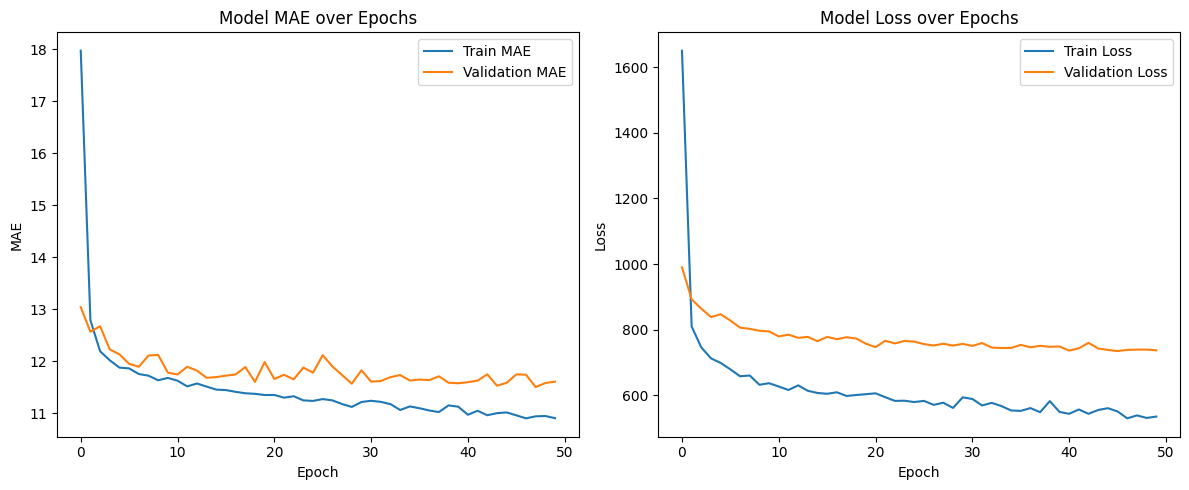

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss_nn, mae_nn = model.evaluate(X_test_scaled, y_test, verbose=0)

y_pred_nn = model.predict(X_test_scaled, verbose=0)
r2_nn = r2_score(y_test, y_pred_nn)

print("\n-----------------------------")
print("Neural Network Model Evaluation")
print(f"Mean Absolute Error (MAE): {mae_nn:.2f}")
print(f"Mean Squared Error (MSE): {loss_nn:.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(loss_nn):.2f}")
print(f"R-squared (R2): {r2_nn:.2f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Neural Network Model Testing

here we are going to make a prediction sentence for a hypothetical new input.

In [ ]:
sample_in_data = pd.DataFrame({
    'charge_number': [1],
    'sentence_year': [2023],
    'race': ['HISPANIC'],
    'gender': ['M'],
    'age_group': ['22-30'],
    'offense': ['Assault'],
    'offense_type': ['Violent'],
    'homicide_type': ['Unknown'],
    'offense_severity_group': ['M1']
})

# Perform one-hot encoding on the sample data
# Use the same categorical features identified during training
sample_in_encoded_temp = pd.get_dummies(sample_in_data, columns=categorical_features)

# Reindex to align columns with the training data's one-hot encoded features (X_train_scaled.columns)
# This adds any missing columns as 0 and removes any extra columns from the sample
sample_in_en = sample_in_encoded_temp.reindex(columns=X_train_scaled.columns, fill_value=0)

# Scale numerical features using the *same scaler* fitted on the training data
sample_in_en[numerical_features] = scaler.transform(sample_in_en[numerical_features])

print("Sample Input Data (preprocessed and scaled):")
display(sample_in_en)

Sample Input Data (preprocessed and scaled):


,charge_number,sentence_year,race_BLACK,race_HISPANIC,race_NATIVE AMERICAN,race_OTHER OR UNKNOWN,race_PACIFIC ISLANDER,race_WHITE,gender_M,gender_UNKNOWN,...,offense_severity_group_D4,offense_severity_group_M1,offense_severity_group_M2,offense_severity_group_M3,offense_severity_group_M4,offense_severity_group_M5,offense_severity_group_M6,offense_severity_group_M7,offense_severity_group_M8,offense_severity_group_M9
0,-0.377472,2.959584,0,True,0,0,0,0,True,0,...,0,True,0,0,0,0,0,0,0,0


In [ ]:
predicted_sentence_length = model.predict(sample_in_en, verbose=0)[0][0]

print(f"\nSentence imposed in months prediction: {predicted_sentence_length:.2f} months")


Sentence imposed in months prediction: 81.09 months


The third model we used is a 2-layer neural network over 50 epochs. Its performance metrics are an MAE of 11.35 months, RMSE of 24.31 months, and an R2 factor of 0.81. Based on these metrics, the neural network has the best performance of the three models so far, with the lowest MAE and the highest R2. Even though there isn’t much improvement from the linear regression model, this small improvement shows us that there is likely a linear relationship between our features and the sentence length and that the added complexity of the neural network only captures marginal additional signal. Also, the training and validation loss curve converge over epochs, showing us that the model is not overfitting. Across all three models, the R2 ranging from 0.79-0.81 shows us that our feature set captures the majority of what influences sentence length.


### Model 4: Linear Regression with Broader Features

We define a new set of features that are broader as requested. then re-apply one-hot encoding and split the data and train the model again.

In [ ]:
target = 'sentence_imposed_months'
y = sentences[target]

broader_features = [
    'charge_number',
    'sentence_year',
    'race',
    'gender',
    'age_group',
    'offense',
]

X_broad = sentences[broader_features]

categorical_features_broad = X_broad.select_dtypes(include='object').columns
numerical_features_broad = X_broad.select_dtypes(exclude='object').columns

print(f"Target variable: {target}")
print(f"Number of broader features: {len(broader_features)}")
print(f"Broader Categorical features: {list(categorical_features_broad)}")
print(f"Broader Numerical features: {list(numerical_features_broad)}")

X_broad = pd.get_dummies(X_broad, columns=categorical_features_broad, drop_first=True)

print(f"\nShape of features DataFrame after broader one-hot: {X_broad.shape}")
print("First 5 rows of broader features after encoding:")
display(X_broad.head())

Target variable: sentence_imposed_months
Number of broader features: 6
Broader Categorical features: ['race', 'gender', 'age_group', 'offense']
Broader Numerical features: ['charge_number', 'sentence_year']

Shape of features DataFrame after broader one-hot: (24676, 248)
First 5 rows of broader features after encoding:


,charge_number,sentence_year,race_BLACK,race_HISPANIC,race_NATIVE AMERICAN,race_OTHER OR UNKNOWN,race_PACIFIC ISLANDER,race_WHITE,gender_M,gender_UNKNOWN,...,offense_Unlawful Possession of a Firearm,offense_Unlawful Possession of a Firearm (Crime of Violence),offense_Unlawful Possession of a Firearm (Fugitive from Justice),offense_Unlawful Possession of a Firearm (Intrafamily Offense),offense_Unlawful Possession of a Firearm (Order to Relinquish),offense_Unlawful Possession of a Firearm (Prior Conviction Under Chapter 45),offense_Uttering,offense_VOLUNTARY MAN. WHILE ARMED,"offense_Vandalizing, Damaging, Destroying, Taking Property of a Government Official",offense_Voluntary Manslaughter
0,3,2020,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,7,2020,True,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
2,3,2020,True,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
3,4,2020,True,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
4,1,2020,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


split this new and broader feature set into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train_broad, X_test_broad, y_train_broad, y_test_broad = train_test_split(
    X_broad, y, test_size=0.2, random_state=42
)

print(f"Training features shape (broader): {X_train_broad.shape}")
print(f"Testing features shape (broader): {X_test_broad.shape}")
print(f"Training target shape (broader): {y_train_broad.shape}")
print(f"Testing target shape (broader): {y_test_broad.shape}")

Training features shape (broader): (19740, 248)
Testing features shape (broader): (4936, 248)
Training target shape (broader): (19740,)
Testing target shape (broader): (4936,)


train a Lin Reg model using broader features and evaluate performance

-----------------------------
Linear Regression Model Evaluation (Broader Features)
Mean Absolute Error (MAE): 14.10
Mean Squared Error (MSE): 839.63
Root Mean Squared Error (RMSE): 28.98
R-squared (R2): 0.73

-----------------------------
Feature Importance from Linear Regression with Broad Features


,Feature,Coefficient,Absolute_Coefficient
5,offense,21985.769064,21985.769064
4,age_group,33.939384,33.939384
2,race,32.165498,32.165498
3,gender,13.030712,13.030712
0,charge_number,0.697644,0.697644
1,sentence_year,-0.601678,0.601678


/tmp/ipykernel_6978/3482726142.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Absolute_Coefficient', y='Feature', data=plot_df, palette='viridis')


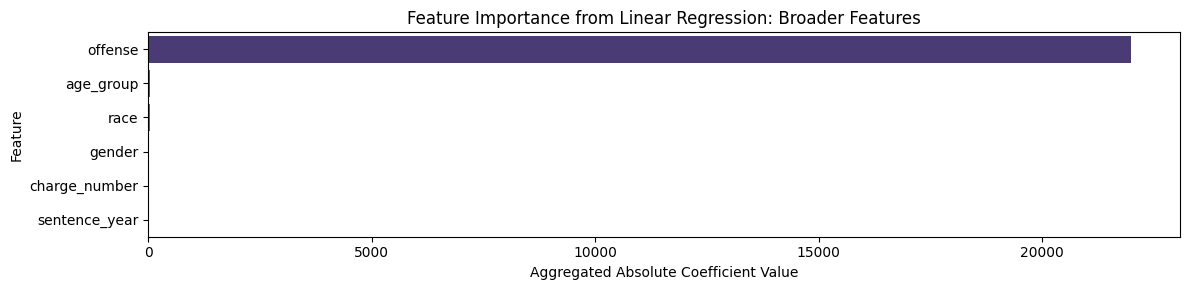

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

lin_model_broad = LinearRegression()
lin_model_broad.fit(X_train_broad, y_train_broad)

y_pred_lr_broad = lin_model_broad.predict(X_test_broad)

mae_lr_broad = mean_absolute_error(y_test_broad, y_pred_lr_broad)
mse_lr_broad = mean_squared_error(y_test_broad, y_pred_lr_broad)
rmse_lr_broad = np.sqrt(mse_lr_broad)
r2_lr_broad = r2_score(y_test_broad, y_pred_lr_broad)

print("-----------------------------")
print("Linear Regression Model Evaluation (Broader Features)")
print(f"Mean Absolute Error (MAE): {mae_lr_broad:.2f}")
print(f"Mean Squared Error (MSE): {mse_lr_broad:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr_broad:.2f}")
print(f"R-squared (R2): {r2_lr_broad:.2f}")

coefs_broad = pd.DataFrame({
    'Feature': X_broad.columns,
    'Coefficient': lin_model_broad.coef_
})
coefs_broad['Absolute_Coefficient'] = np.abs(coefs_broad['Coefficient'])

aggregated_coefs_for_plot = []

for feature_name in broader_features:
    if feature_name in numerical_features_broad:
        coeff_val = coefs_broad[coefs_broad['Feature'] == feature_name]['Coefficient'].values
        if len(coeff_val) > 0:
            aggregated_coefs_for_plot.append({'Feature': feature_name, 'Coefficient': coeff_val[0], 'Absolute_Coefficient': abs(coeff_val[0])})
    elif feature_name in categorical_features_broad:
        related_cols = [col for col in coefs_broad['Feature'] if col.startswith(f'{feature_name}_')]
        if related_cols:
            sum_abs_coeff = coefs_broad[coefs_broad['Feature'].isin(related_cols)]['Absolute_Coefficient'].sum()
            aggregated_coefs_for_plot.append({'Feature': feature_name, 'Coefficient': sum_abs_coeff, 'Absolute_Coefficient': sum_abs_coeff})

plot_df = pd.DataFrame(aggregated_coefs_for_plot)
plot_df = plot_df.sort_values(by='Absolute_Coefficient', ascending=False)

print("\n-----------------------------")
print("Feature Importance from Linear Regression with Broad Features")
display(plot_df)

plt.figure(figsize=(12, min(8, max(len(plot_df) * 0.5, 3))))
sns.barplot(x='Absolute_Coefficient', y='Feature', data=plot_df, palette='viridis')
plt.title('Feature Importance from Linear Regression: Broader Features')
plt.xlabel('Aggregated Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The fourth model we used is a linear regression using a broader and reduced feature set. It follows the same methodology as the first model, but it excludes offense type, homicide type, and offense severity group. This means it only has the columns charge number, sentence year, race, gender, age group, and the specific offense. This allowed us to isolate the demographic and charge-level features and see their effect without the influence of severity data. The results show that there is a drop in performance. The R2 falls to 0.73, MAE increases to 14.10 months, and RMSE rises to 28.98 months. This confirms that the severity of the offense and type are critical factors in predicting sentence length. However, the fact that this reduced model still has an R2 value of 0.73 is a significant finding. Demographic variables combine with the specific offense explain almost ¾ of the variance in sentence length. This supports our hypothesis that demographic factors do play a measurable role in sentencing outcomes.


---

### Model 5: Predicting serve_ratio

In [ ]:
targ_serve_ratio = 'serve_ratio'
y_serve = sentences[targ_serve_ratio]

feats_for_serve_ratio = [
    'charge_number',
    'sentence_year',
    'race',
    'gender',
    'age_group',
    'offense',
    'offense_type',
    'homicide_type',
    'offense_severity_group',
    'sentence_type'
]

X_serve = sentences[feats_for_serve_ratio]

cat_features_serve = X_serve.select_dtypes(include='object').columns
num_features_serve = X_serve.select_dtypes(exclude='object').columns

print(f"Target variable: {targ_serve_ratio}")
print(f"Number of features: {len(feats_for_serve_ratio)}")
print(f"Categorical features: {list(cat_features_serve)}")
print(f"Numerical features: {list(num_features_serve)}")

X_serve = pd.get_dummies(X_serve, columns=cat_features_serve, drop_first=True)

print(f"\nShape of features DataFrame after one-hot: {X_serve.shape}")
print("First 5 rows of features after encoding:")
display(X_serve.head())

Target variable: serve_ratio
Number of features: 10
Categorical features: ['race', 'gender', 'age_group', 'offense', 'offense_type', 'homicide_type', 'offense_severity_group', 'sentence_type']
Numerical features: ['charge_number', 'sentence_year']

Shape of features DataFrame after one-hot: (24676, 276)
First 5 rows of features after encoding:


,charge_number,sentence_year,race_BLACK,race_HISPANIC,race_NATIVE AMERICAN,race_OTHER OR UNKNOWN,race_PACIFIC ISLANDER,race_WHITE,gender_M,gender_UNKNOWN,...,offense_severity_group_M6,offense_severity_group_M7,offense_severity_group_M8,offense_severity_group_M9,sentence_type_Indeterminate,sentence_type_Indeterminate/Incarceration,sentence_type_Life,sentence_type_Long Split,sentence_type_Probation,sentence_type_Short Split
0,3,2020,True,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
1,7,2020,True,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
2,3,2020,True,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
3,4,2020,True,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
4,1,2020,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


again split the data into training and testing sets for the serve_ratio prediction.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_serve, X_test_serve, y_train_serve, y_test_serve = train_test_split(
    X_serve, y_serve, test_size=0.2, random_state=42
)

print(f"Training features shape: {X_train_serve.shape}")
print(f"Testing features shape: {X_test_serve.shape}")
print(f"Training target shape: {y_train_serve.shape}")
print(f"Testing target shape: {y_test_serve.shape}")

Training features shape: (19740, 276)
Testing features shape: (4936, 276)
Training target shape: (19740,)
Testing target shape: (4936,)


train a Linear Regression model to predict the serve_ratio and evaluate its performance

Linear Regression Model Evaluation: Serve Ratio
Mean Absolute Error (MAE): 0.0335
Mean Squared Error (MSE): 0.0055
Root Mean Squared Error (RMSE): 0.0742
R-squared (R2): 0.9713

-----------------------------
Feature Importance from Linear Regression: Serve Ratio


,Feature,Coefficient,Absolute_Coefficient
5,offense,4.712531,4.712531
9,sentence_type,3.440841,3.440841
8,offense_severity_group,0.160804,0.160804
2,race,0.154722,0.154722
6,offense_type,0.069909,0.069909
4,age_group,0.037011,0.037011
3,gender,0.014488,0.014488
7,homicide_type,0.013501,0.013501
1,sentence_year,-0.000058,0.000058
0,charge_number,0.000045,0.000045


/tmp/ipykernel_6978/2670000058.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Absolute_Coefficient', y='Feature', data=plot_df_serve, palette='viridis')


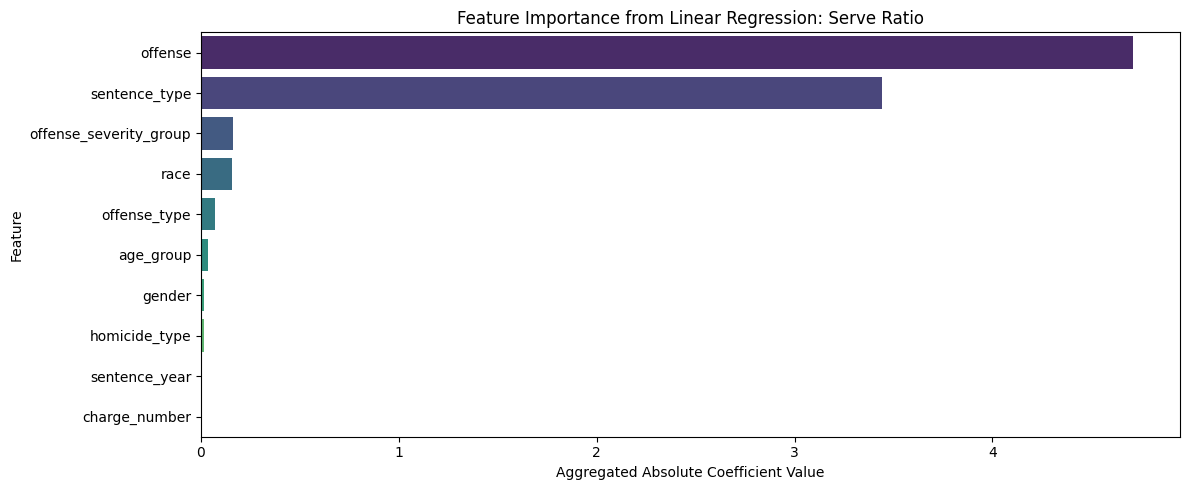

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

lin_model_serve_ratio = LinearRegression()
lin_model_serve_ratio.fit(X_train_serve, y_train_serve)

y_pred_serve = lin_model_serve_ratio.predict(X_test_serve)

mae_serve = mean_absolute_error(y_test_serve, y_pred_serve)
mse_serve = mean_squared_error(y_test_serve, y_pred_serve)
rmse_serve = np.sqrt(mse_serve)
r2_serve = r2_score(y_test_serve, y_pred_serve)

print("Linear Regression Model Evaluation: Serve Ratio")
print(f"Mean Absolute Error (MAE): {mae_serve:.4f}")
print(f"Mean Squared Error (MSE): {mse_serve:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_serve:.4f}")
print(f"R-squared (R2): {r2_serve:.4f}")

coefs_serve = pd.DataFrame({
    'Feature': X_serve.columns,
    'Coefficient': lin_model_serve_ratio.coef_
})
coefs_serve['Absolute_Coefficient'] = np.abs(coefs_serve['Coefficient'])

agg_coefs_serve_plot = []

for feature_name in feats_for_serve_ratio:
    if feature_name in num_features_serve:
        coeff_val = coefs_serve[coefs_serve['Feature'] == feature_name]['Coefficient'].values
        if len(coeff_val) > 0:
            agg_coefs_serve_plot.append({'Feature': feature_name, 'Coefficient': coeff_val[0], 'Absolute_Coefficient': abs(coeff_val[0])})
    elif feature_name in cat_features_serve:
        related_cols = [col for col in coefs_serve['Feature'] if col.startswith(f'{feature_name}_')]
        if related_cols:
            sum_abs_coeff = coefs_serve[coefs_serve['Feature'].isin(related_cols)]['Absolute_Coefficient'].sum()
            agg_coefs_serve_plot.append({'Feature': feature_name, 'Coefficient': sum_abs_coeff, 'Absolute_Coefficient': sum_abs_coeff})

plot_df_serve = pd.DataFrame(agg_coefs_serve_plot)
plot_df_serve = plot_df_serve.sort_values(by='Absolute_Coefficient', ascending=False)

print("\n-----------------------------")
print("Feature Importance from Linear Regression: Serve Ratio")
display(plot_df_serve)

plt.figure(figsize=(12, min(8, max(len(plot_df_serve) * 0.5, 3))))
sns.barplot(x='Absolute_Coefficient', y='Feature', data=plot_df_serve, palette='viridis')
plt.title('Feature Importance from Linear Regression: Serve Ratio')
plt.xlabel('Aggregated Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


Our fifth and final model predicts the serve ratio, which is the proportion of an imposed sentence that a defendant is actually expected to serve. This is a highly important distinction that the sentence length cannot really capture. We trained a linear regression model using the same complete features as Model 1, with the addition of sentence type. The results were more surprising: the R2 is 0.97, MAE is 0.034, and RMSE is 0.074. This means our model predicts the serve ratio with amazing accuracy. This suggests that the proportion of a sentence actually served is determined by the factors like sentence type, offense severity, and offense classification. There is very little unexplained variance. This is different from the sentence length, because in that, the demographic variables contribute to predictions more meaningfully. Together, models 4 and 5 both show much more in relation to the predictions that demographic characteristics appear.


Insights and Conclusion
To answer our core research questions, we trained five models on the DC Felony Sentencing dataset.

Following are the key insights we found:

Offense type and severity are the dominant predictors of sentence length. This did not surprise us, as severity and type of offense naturally predict sentence length. Every model we trained reflected this, the features related to the severity of the crime were consistently the most influential in predicting sentence length. This is what we initially expected and also shows that the legal system is working as intended for DC sentences.
Removing offense-level features significantly weakens predictions. Model 4, which we trained very similar to Model 1 except for the fact that it only included broader features, showed a drop in R2 from 0.79 to 0.73, which means that demographic variables like race, gender, and age do influence the variance in sentence length.
All three types of models perform consistently. Linear regression, random forest, and the neural network achieved R2 values of 0.79, 0.80, and 0.81 respectively, with RMSE values ranging between 24 and 25 months. The fact that these models performed almost identically proves that the relationships in the data are mostly linear.
Serve ratio is predictable. Model 5 had the highest performance by far. This means that given the features available, we can predict the proportion of a sentence the defendant will actually end up serving with very high accuracy.

Limitations
Correlation is not causation. The fact that demographic variables seem to change the models does not mean that the judges are making decisions based on race or gender. There may be confounding variables that we have not analyzed that end up changing our results.
This dataset only covers the DC area. Our findings are specific to this area so we cannot generalize them to other jurisdictions which have different guidelines or sentencing.
Missing data changes our information. The missing values were filled with column medians and categorical missing values were filled with “Unknown.” This may change the model performance, especially for columns where there is a lot of missing data (like homicide_type).
Arrests and crimes datasets were not used in final models. While we loaded and cleaned these datasets with the intention of merging them with the sentencing datasets, time constraints limited our ability to merge them with sentencing data. Incorporating these datasets in the future can tell us much more about the context of the crimes and how sentences ended up.

Conclusion
At the start of this project, we wanted to answer two major questions:
(1) what factors most strongly influence felony sentencing outcomes in DC? And
(2) do demographic characteristics play a role in sentencing outcomes?
Our project clearly answers both of these questions.

Offense type and severity are the strongest predictors of sentence length, but they do not account for the entire outcome. Our hypothesis tests showed us that there were statistically significant differences in sentencing outcomes across gender groups even when the sentences had the same offense categories. While we cannot conclude the reason for this bias, the patterns that we found are consistent with broader concerns about fairness in the criminal justice system and if we had more time, this is something we would research further.

The most surprising outcome of our project is how predictable the serve ratio is. The R2 value of 0.97 suggests that once the sentence is handed, how much of it the defendant actually serves is determined by rule-based factors. By contrast, the sentence length itself has some variance that is explained by demographic factors.

We believe that analyzing this issue with data is a good starting point for actually understanding and investigating these issues in the legal system. By making our methodology transparent, we hope that this is reproducible and others can further our research about the power and responsibility that can be made clear by data science.




In [3]:
!jupyter nbconvert --to html "/content/Final Submission Code.ipynb"


[NbConvertApp] WARNING | pattern '/content/Final Submission Code.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=